# Module 06 — EDA Interactive Notebook
## ShopSmart Retail Group Sales Analysis

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of specific findings
- Deeper investigation of anomalies

**Business questions we answer here:**
1. Which product categories and stores generate the highest revenue per sale?
2. Which stores are underperforming relative to the category average?
3. Does discount percentage correlate with total sales amount?
4. Which specific retail transactions are statistical anomalies?

In [1]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / "config.py").exists() and _root != _root.parent:
    _root = _root.parent

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library

# Tell matplotlib to display plots directly in the notebook (not in a separate window)
%matplotlib inline

# Set figure defaults for readable notebook charts
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

from config import DATA_PATH, REPORTS_DIR, TOP_N_GROUPS

# Create folder for notebook chart outputs
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector

print(f"Project root: {_root}")
print(f"Data path:    {DATA_PATH}")
print(f"Reports dir:  {REPORTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

2026-05-23 20:46:14 [INFO] Database connection successful.


Project root: c:\student-projects eda\P01-retail-eda
Data path:    C:\student-projects eda\P01-retail-eda\data\processed\processed-data.csv
Reports dir:  C:\student-projects eda\P01-retail-eda\reports
Figures dir:  C:\student-projects eda\P01-retail-eda\reports\figures


In [2]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results["profile"]

print("=" * 50)
print("  RETAIL DATASET OVERVIEW")
print("=" * 50)
print(f"  Rows:          {p['rows']:,}")
print(f"  Columns:       {p['columns']}")
print(f"  Numeric cols:  {p['numeric_cols']}")
print(f"  Text cols:     {p['categorical_cols']}")
print(f"  Missing vals:  {p['total_nulls']:,} ({p['null_pct']}%)")
print(f"  Memory:        {p['memory_mb']} MB")

2026-05-23 20:46:22 [INFO] EDAEngine initialised — industry: retail
2026-05-23 20:46:22 [INFO] [EDA] Loading: processed-data.csv
2026-05-23 20:46:22 [INFO] [EDA] Loaded 50 rows × 41 columns
2026-05-23 20:46:22 [INFO] [EDA] Column types: 16 numeric, 18 categorical
2026-05-23 20:46:22 [INFO] [EDA] Computing dataset profile...
2026-05-23 20:46:22 [INFO] [EDA] Profile complete — 50 rows | 0.0% nulls


  RETAIL DATASET OVERVIEW
  Rows:          50
  Columns:       41
  Numeric cols:  16
  Text cols:     18
  Missing vals:  0 (0.0%)
  Memory:        0.07 MB


In [3]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith("_")],
    errors="ignore"
)

print("Analysis dataframe created successfully.")
print(f"Rows: {analysis_df.shape[0]:,}")
print(f"Columns: {analysis_df.shape[1]}")
display(analysis_df.head())

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
desc = analysis_df.describe().round(2).T
desc

Analysis dataframe created successfully.
Rows: 50
Columns: 38


,sale_id,sale_date,quantity,unit_price,discount_pct,total_amount,payment_method,customer_type,product_id,product_name,...,return_status,gross_sales_amount,discount_amount,net_sales_amount,estimated_profit,sale_month,total_amount_is_outlier,net_sales_amount_is_outlier,gross_sales_amount_is_outlier,is_any_outlier
0,1,2022-12-22,5,1812.16,20.0,7248.64,Cash,Regular,131,Various Beverages Model-683,...,Unknown,9060.80,1812.16,6352.14,5456.05,2022-12,False,False,False,False
1,2,2024-03-24,5,619.79,0.0,3098.95,Credit Card,Loyalty,823,Apple Smartphones Model-804,...,Unknown,3098.95,0.00,2202.44,909.23,2024-03,False,False,False,False
2,3,2022-02-01,6,1433.26,15.0,7309.63,Cash,Regular,794,L'Oreal Skincare Model-705,...,Unknown,8599.56,1289.93,6413.12,4597.03,2022-02,False,False,False,False
3,4,2022-07-18,9,1516.56,5.0,12966.59,Credit Card,First-time,42,Levi's Jeans Model-882,...,Unknown,13649.04,682.45,12070.08,6574.06,2022-07,False,False,False,False
4,5,2024-05-15,4,1599.24,10.0,5757.26,Credit Card,First-time,531,Wilson Equipment Model-457,...,Unknown,6396.96,639.70,4860.76,3672.56,2024-05,False,False,False,False


,count,mean,std,min,25%,50%,75%,max
sale_id,50.0,28.92,16.15,1.00,15.50,29.50,42.50,55.00
quantity,50.0,5.54,2.58,1.00,3.25,5.50,7.00,10.00
unit_price,50.0,1108.94,608.46,36.43,596.63,1244.56,1592.38,1983.22
discount_pct,50.0,6.80,7.54,0.00,0.00,5.00,13.75,20.00
total_amount,50.0,5861.82,4365.42,145.72,2135.57,5059.23,8682.76,16823.79
product_id,50.0,538.48,288.33,42.00,297.25,594.00,788.25,1000.00
unit_cost,50.0,144.60,249.09,1.71,12.70,33.40,54.64,870.34
margin_pct,50.0,60.27,13.88,23.00,54.54,64.46,69.38,79.19
store_id,50.0,6.74,3.50,1.00,4.00,7.00,10.00,13.00
sqft,50.0,11610.00,3977.35,5000.00,10000.00,10000.00,13000.00,20000.00


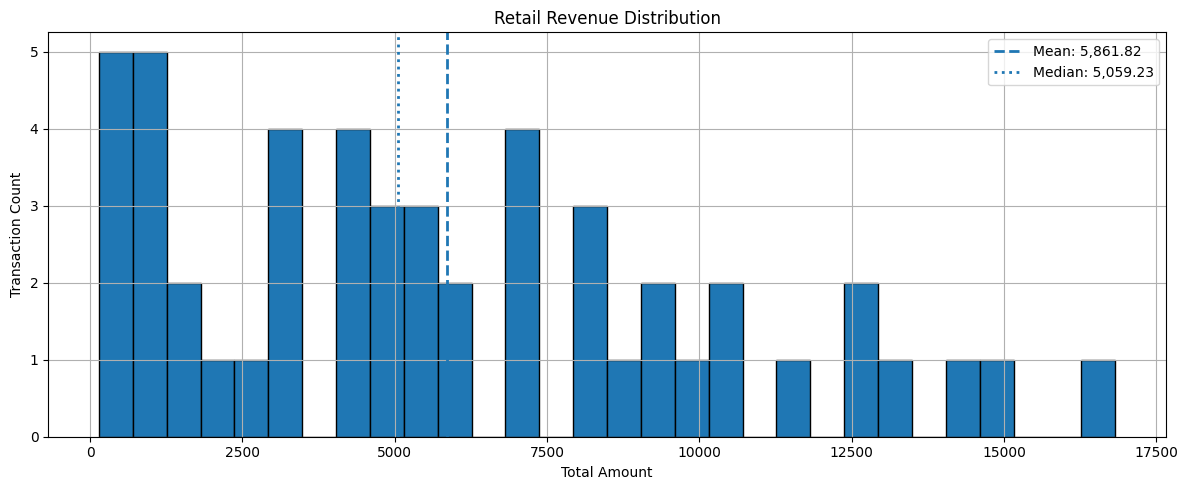

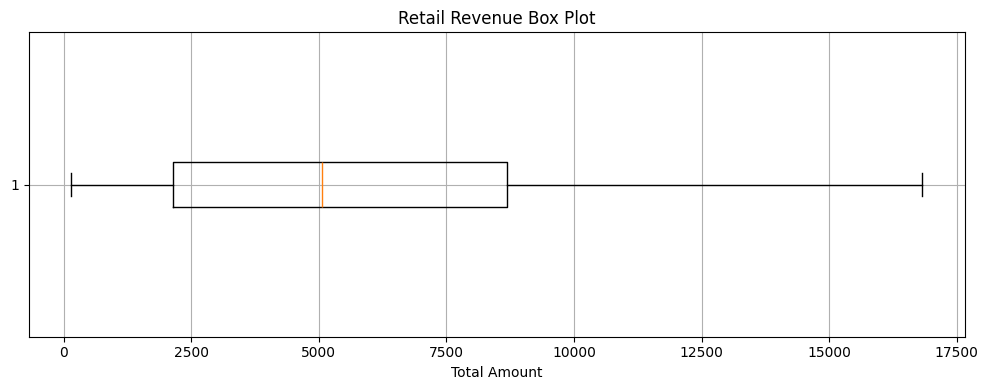

In [4]:
# ── Cell 4: Revenue Distribution — Histogram and Box Plot ────────────────
# A histogram shows how values are distributed across ranges.
# BINS divide the value range into equal segments and count how many
# values fall in each bin.
#
# What to look for:
#   Normal pattern      → transactions cluster around a typical sale value
#   Right skewed        → most transactions are low, a few are very high
#   Extreme values      → possible bulk purchases, pricing errors, or data issues

if "total_amount" in analysis_df.columns:
    revenue = pd.to_numeric(analysis_df["total_amount"], errors="coerce").dropna()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(revenue, bins=30, edgecolor="black")
    ax.axvline(revenue.mean(), linestyle="--", linewidth=2, label=f"Mean: {revenue.mean():,.2f}")
    ax.axvline(revenue.median(), linestyle=":", linewidth=2, label=f"Median: {revenue.median():,.2f}")
    ax.set_title("Retail Revenue Distribution")
    ax.set_xlabel("Total Amount")
    ax.set_ylabel("Transaction Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "retail_revenue_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(revenue, vert=False)
    ax.set_title("Retail Revenue Box Plot")
    ax.set_xlabel("Total Amount")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "retail_revenue_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'total_amount' not found.")


,category,total_sales,total_revenue,average_revenue_per_sale,rank
5,Home,3,33637.94,11212.65,1
3,Electronics,9,61007.88,6778.65,2
2,Clothing,10,63044.79,6304.48,3
1,Books,6,34945.66,5824.28,4
6,Sports,9,45068.00,5007.56,5
4,Food,6,28002.09,4667.02,6
0,Beauty,7,27384.62,3912.09,7


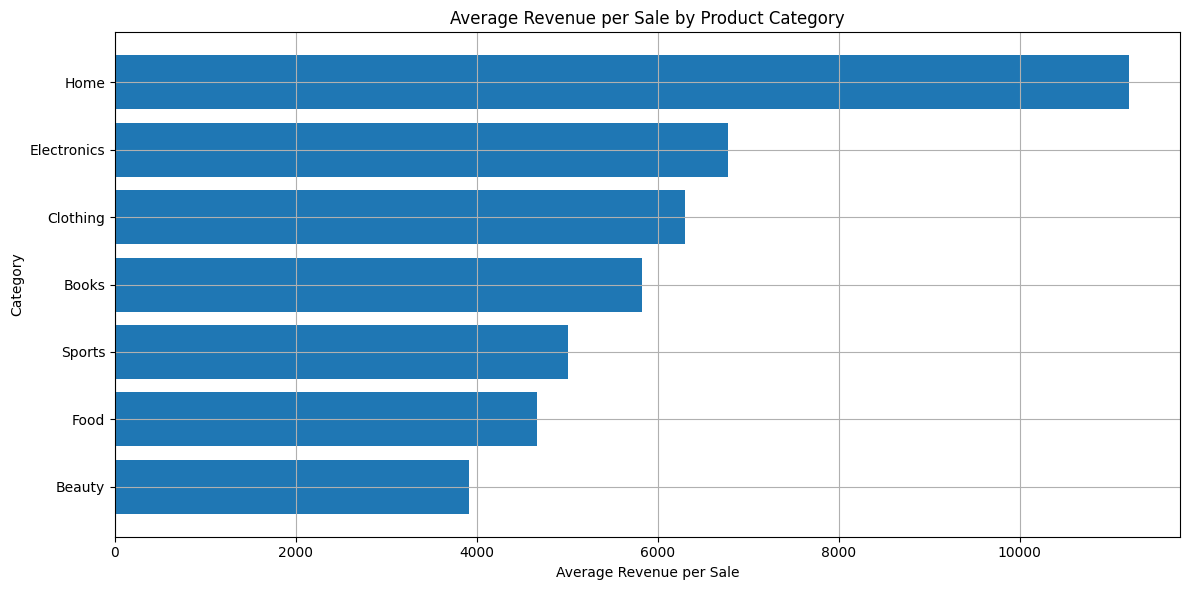

In [5]:
# ── Cell 5: Revenue Performance by Category ──────────────────────────────
# Bar charts are the most intuitive way to compare group-level metrics.
# Here we rank product categories by average revenue per sale.

if {"category", "total_amount"}.issubset(analysis_df.columns):
    category_revenue = (
        analysis_df
        .groupby("category", dropna=False)
        .agg(
            total_sales=("total_amount", "count"),
            total_revenue=("total_amount", "sum"),
            average_revenue_per_sale=("total_amount", "mean")
        )
        .reset_index()
        .sort_values("average_revenue_per_sale", ascending=False)
    )

    category_revenue["rank"] = range(1, len(category_revenue) + 1)

    display(category_revenue.round(2))

    plot_df = category_revenue.sort_values("average_revenue_per_sale", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["category"].astype(str), plot_df["average_revenue_per_sale"])
    ax.set_title("Average Revenue per Sale by Product Category")
    ax.set_xlabel("Average Revenue per Sale")
    ax.set_ylabel("Category")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "revenue_by_category.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: category and total_amount.")

,store_name,total_sales,total_revenue,average_revenue_per_sale,rank
0,Atlanta Central,7,60930.36,8704.34,1
6,LA Main,4,32155.80,8038.95,2
12,Vancouver BC,1,7285.95,7285.95,3
9,Midtown Express,4,26877.58,6719.40,4
4,Downtown Flagship,2,13026.86,6513.43,5
10,Seattle Hub,6,33344.85,5557.48,6
7,London UK,4,22174.80,5543.70,7
5,Houston South,1,4950.14,4950.14,8
1,Boston Common,2,9717.83,4858.92,9
2,Chicago North,8,38442.78,4805.35,10


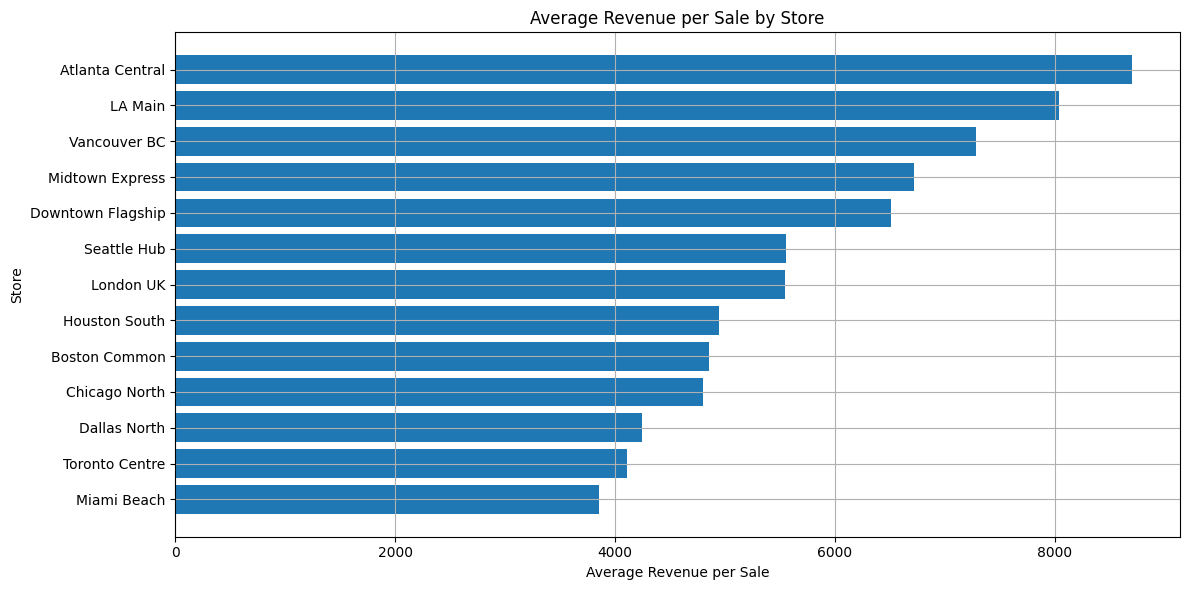

In [6]:
# ── Cell 6: Revenue Performance by Store ─────────────────────────────────
# This shows which stores generate the highest revenue per sale.
# It also helps identify underperforming stores before the board meeting.

if {"store_name", "total_amount"}.issubset(analysis_df.columns):
    store_revenue = (
        analysis_df
        .groupby("store_name", dropna=False)
        .agg(
            total_sales=("total_amount", "count"),
            total_revenue=("total_amount", "sum"),
            average_revenue_per_sale=("total_amount", "mean")
        )
        .reset_index()
        .sort_values("average_revenue_per_sale", ascending=False)
    )

    store_revenue["rank"] = range(1, len(store_revenue) + 1)

    display(store_revenue.round(2))

    plot_df = store_revenue.sort_values("average_revenue_per_sale", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["store_name"].astype(str), plot_df["average_revenue_per_sale"])
    ax.set_title("Average Revenue per Sale by Store")
    ax.set_xlabel("Average Revenue per Sale")
    ax.set_ylabel("Store")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "revenue_by_store.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: store_name and total_amount.")

In [7]:
# ── Cell 7: Store Performance Relative to Category Average ───────────────
# The business question asks:
# Which stores are underperforming relative to the category average?
#
# We compare each store/category average revenue per sale against the
# overall category average revenue per sale.

required_cols = {"store_name", "category", "total_amount"}

if required_cols.issubset(analysis_df.columns):
    store_category = (
        analysis_df
        .groupby(["category", "store_name"], dropna=False)
        .agg(
            sales_count=("total_amount", "count"),
            store_category_avg=("total_amount", "mean")
        )
        .reset_index()
    )

    category_avg = (
        analysis_df
        .groupby("category", dropna=False)
        .agg(category_avg=("total_amount", "mean"))
        .reset_index()
    )

    performance = store_category.merge(category_avg, on="category", how="left")
    performance["difference_from_category_avg"] = (
        performance["store_category_avg"] - performance["category_avg"]
    ).round(2)

    performance["performance_flag"] = np.where(
        performance["difference_from_category_avg"] < 0,
        "Underperforming",
        "At or Above Average"
    )

    underperforming = (
        performance[performance["performance_flag"] == "Underperforming"]
        .sort_values("difference_from_category_avg")
    )

    print("Underperforming store/category combinations:")
    display(underperforming.round(2))

else:
    print("Required columns not found: store_name, category, total_amount.")

Underperforming store/category combinations:


,category,store_name,sales_count,store_category_avg,category_avg,difference_from_category_avg,performance_flag
28,Home,Boston Common,1,4405.32,11212.65,-6807.33,Underperforming
21,Electronics,London UK,1,1021.20,6778.65,-5757.45,Underperforming
10,Clothing,Dallas North,1,1174.63,6304.48,-5129.85,Underperforming
24,Food,Midtown Express,1,340.29,4667.02,-4326.73,Underperforming
5,Books,Miami Beach,1,1679.48,5824.28,-4144.80,Underperforming
35,Sports,Toronto Centre,1,1046.38,5007.56,-3961.18,Underperforming
26,Food,Toronto Centre,1,845.75,4667.02,-3821.27,Underperforming
2,Beauty,LA Main,1,500.76,3912.09,-3411.33,Underperforming
15,Clothing,Seattle Hub,1,3043.32,6304.48,-3261.16,Underperforming
17,Electronics,Chicago North,2,3869.39,6778.65,-2909.26,Underperforming


  DISCOUNT IMPACT
Pearson correlation between discount_pct and total_amount: -0.0902
Interpretation: Discount percentage has weak or negligible linear relationship with transaction totals.


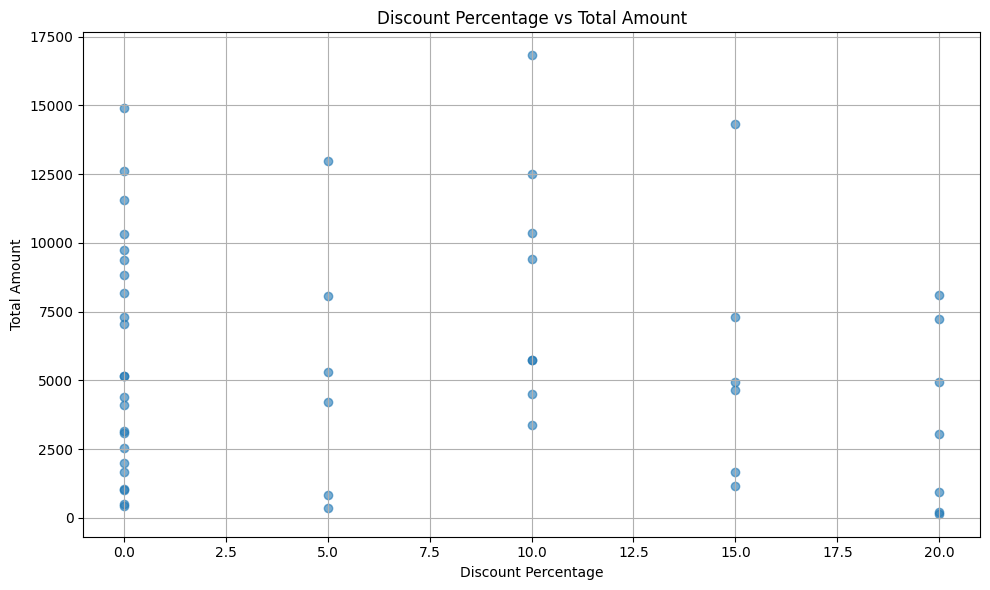

In [8]:
# ── Cell 8: Discount Impact — Pearson Correlation ───────────────────────
# The business question asks:
# Does offering higher discounts actually correlate with higher sales volume?
#
# Here we compute the Pearson correlation between discount_pct and total_amount.
# Positive correlation: higher discounts are associated with higher transaction totals.
# Negative correlation: higher discounts are associated with lower transaction totals.
# Near zero: discount has little linear relationship with transaction totals.

if {"discount_pct", "total_amount"}.issubset(analysis_df.columns):
    discount = pd.to_numeric(analysis_df["discount_pct"], errors="coerce")
    revenue = pd.to_numeric(analysis_df["total_amount"], errors="coerce")

    corr = discount.corr(revenue)

    print("=" * 60)
    print("  DISCOUNT IMPACT")
    print("=" * 60)
    print(f"Pearson correlation between discount_pct and total_amount: {corr:.4f}")

    if corr < -0.3:
        print("Interpretation: Higher discounts are associated with lower transaction totals.")
    elif corr > 0.3:
        print("Interpretation: Higher discounts are associated with higher transaction totals.")
    else:
        print("Interpretation: Discount percentage has weak or negligible linear relationship with transaction totals.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(discount, revenue, alpha=0.6)
    ax.set_title("Discount Percentage vs Total Amount")
    ax.set_xlabel("Discount Percentage")
    ax.set_ylabel("Total Amount")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "discount_vs_total_amount.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: discount_pct and total_amount.")

2026-05-23 20:47:32 [INFO] [EDA] Computing correlation matrix...
2026-05-23 20:47:32 [INFO] [EDA] Correlation: 26 meaningful pairs (threshold |r| > 0.3)


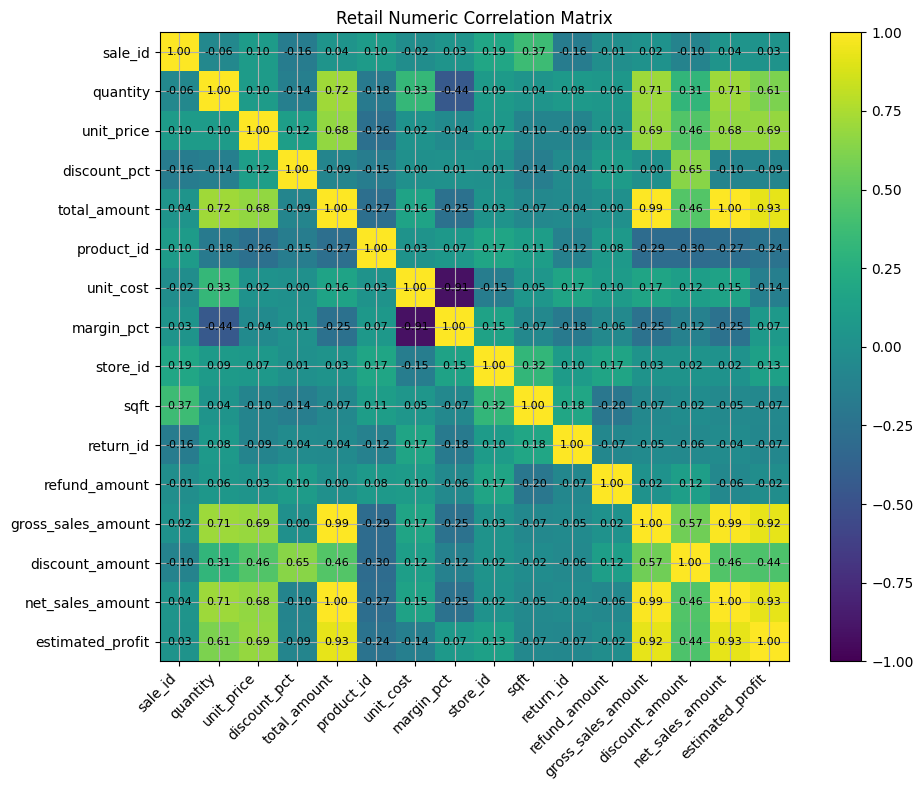

In [9]:
# ── Cell 9: Correlation Heatmap ───────────────────────────────────────────
# A heatmap visualises the entire correlation matrix at once.
# Each cell is coloured by the correlation value:
#   Positive value → variables move together
#   Negative value → one variable rises while the other falls
#   Near zero      → weak linear relationship
#
# This is how analysts quickly identify:
#   - Which retail metrics are strongly related to revenue
#   - Which features are redundant or related to each other

engine.correlation()

numeric_df = analysis_df.select_dtypes(include=["number"])

if numeric_df.shape[1] >= 2:
    corr_df = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_df, vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.columns)

    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    ax.set_title("Retail Numeric Correlation Matrix")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "retail_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

In [10]:
# ── Cell 10: Anomaly Detection ────────────────────────────────────────────
# Now we run the AnomalyDetector on the loaded data.
# Confirmed anomalies are those flagged by BOTH IQR and Z-score.
#
# For retail, the most important anomaly columns are usually:
#   total_amount, quantity, unit_price, discount_pct, refund_amount, margin_pct

detector = AnomalyDetector(engine.df)
detector.run(columns=[
    col for col in [
        "total_amount",
        "quantity",
        "unit_price",
        "discount_pct",
        "refund_amount",
        "margin_pct"
    ]
    if col in engine.df.columns
])

print("Anomaly Detection Summary:")
print(detector.summary().to_string(index=False))
print(f"\nTotal confirmed anomaly rows: {len(detector.confirmed):,}")

if len(detector.confirmed) > 0:
    display(detector.confirmed.head(20))

2026-05-23 20:47:45 [INFO] AnomalyDetector initialised — 50 rows to scan
2026-05-23 20:47:45 [INFO] [ANOMALY] total_amount: IQR=0 | Z-score=0 | Confirmed=0
2026-05-23 20:47:45 [INFO] [ANOMALY] quantity: IQR=0 | Z-score=0 | Confirmed=0
2026-05-23 20:47:45 [INFO] [ANOMALY] unit_price: IQR=0 | Z-score=0 | Confirmed=0
2026-05-23 20:47:45 [INFO] [ANOMALY] discount_pct: IQR=0 | Z-score=0 | Confirmed=0
2026-05-23 20:47:45 [INFO] [ANOMALY] refund_amount: IQR=10 | Z-score=2 | Confirmed=2
2026-05-23 20:47:45 [INFO] [ANOMALY] margin_pct: IQR=4 | Z-score=0 | Confirmed=0
2026-05-23 20:47:45 [INFO] [ANOMALY] Scan complete: 2 confirmed anomaly rows found


Anomaly Detection Summary:
       column  iqr_flagged  zscore_flagged  confirmed_anomalies  anomaly_pct
 total_amount            0               0                    0          0.0
     quantity            0               0                    0          0.0
   unit_price            0               0                    0          0.0
 discount_pct            0               0                    0          0.0
refund_amount           10               2                    2          4.0
   margin_pct            4               0                    0          0.0

Total confirmed anomaly rows: 2


,sale_id,sale_date,quantity,unit_price,discount_pct,total_amount,payment_method,customer_type,product_id,product_name,...,net_sales_amount,estimated_profit,sale_month,total_amount_is_outlier,net_sales_amount_is_outlier,gross_sales_amount_is_outlier,is_any_outlier,_industry,_processed_at,_pipeline_version
26,31,2024-11-08,9,1161.08,10.0,9404.75,Credit Card,Loyalty,777,Dell Laptops Model-918,...,7567.28,4275.40,2024-11,False,False,False,False,retail,2026-05-23T20:09:11.250366,1.0.0
36,41,2024-02-14,6,860.75,0.0,5164.50,Mobile Pay,Regular,701,Various Fiction Model-469,...,5133.70,3455.05,2024-02,False,False,False,False,retail,2026-05-23T20:09:11.250366,1.0.0


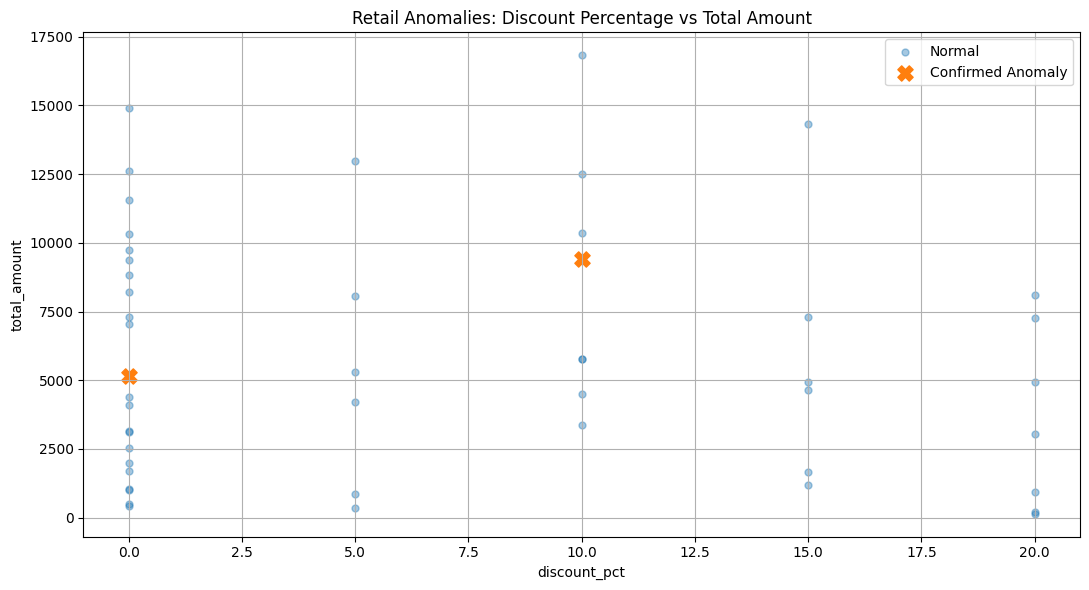

In [11]:
# ── Cell 11: Visualise Anomalies ──────────────────────────────────────────
# Show which rows are anomalies on the scatter plot.
# Normal rows = small circles
# Anomaly rows = large X marks
#
# For retail, total_amount is the main Y-axis because unusual revenue values
# are important for merchandising and sales-performance review.

x_col = "discount_pct" if "discount_pct" in engine.df.columns else None
y_col = "total_amount" if "total_amount" in engine.df.columns else None

if len(detector.confirmed) > 0 and x_col and y_col:
    analysis_df = engine.df.drop(
        columns=[c for c in engine.df.columns if c.startswith("_")],
        errors="ignore"
    )

    normal_mask = ~engine.df.index.isin(detector.confirmed.index)
    normal_rows = analysis_df[normal_mask]
    anomaly_rows = analysis_df[~normal_mask]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.scatter(
        normal_rows[x_col],
        normal_rows[y_col],
        alpha=0.4,
        s=25,
        label="Normal"
    )

    ax.scatter(
        anomaly_rows[x_col],
        anomaly_rows[y_col],
        marker="X",
        s=120,
        label="Confirmed Anomaly"
    )

    ax.set_title("Retail Anomalies: Discount Percentage vs Total Amount")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "retail_anomalies_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

elif len(detector.confirmed) == 0:
    print("No confirmed anomalies to visualise.")
else:
    print("Required plotting columns not found.")

In [12]:
# ── Cell 12: Save Anomalies for Review ───────────────────────────────────
# The anomalies file can be opened in Excel by the merchandising team.
# This supports human investigation of unusual transactions.

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
detector.save_anomalies()

print(f"Anomalies saved to: {REPORTS_DIR / 'anomalies.csv'}")

2026-05-23 20:48:11 [INFO] [ANOMALY] 2 anomaly rows saved: C:\student-projects eda\P01-retail-eda\reports\anomalies.csv


Anomalies saved to: C:\student-projects eda\P01-retail-eda\reports\anomalies.csv


## Summary and Next Steps

You have completed the EDA for this retail dataset. Record your key findings below:

### Key Findings

| Finding | Value | Action |
|---|---|---|
| Top product category by average revenue per sale | *fill in* | Review category strategy |
| Top store by average revenue per sale | *fill in* | Compare against underperforming stores |
| Discount vs revenue correlation | *fill in* | Decide whether discounting is helping |
| Anomaly rows confirmed | *fill in* | Review anomalies.csv |

### Next Steps
- **Merchandising review**: Focus on high-performing and underperforming categories.
- **Store operations review**: Investigate stores below their category average.
- **Discount policy review**: Use the correlation result to decide whether discounts are helping or hurting.
- **Anomaly review**: Open `reports/anomalies.csv` and investigate unusual transactions.

### Questions for the Head of Merchandising
1. Which categories should receive more inventory or promotion?
2. Which stores need operational support or pricing review?
3. Are current discounts improving sales, or are they reducing margin without benefit?